In [69]:
import pandas as pd
import glob
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from  scipy import optimize
from ipywidgets import interact, IntSlider
from scipy.optimize import curve_fit
from matplotlib.animation import FuncAnimation, PillowWriter

<Axes: title={'center': 'Polarization Over Time'}, xlabel='Datetime', ylabel='Polarization'>

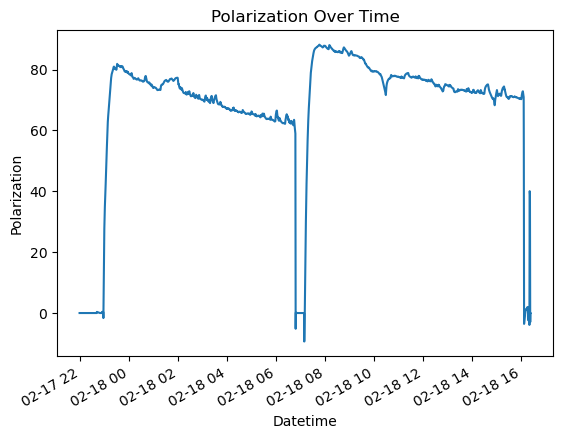

In [2]:
with open("event_json/2009-02-18_16h23m46s.json","r") as eventfile:
    df = pd.read_json(eventfile, lines=True)
df['stop_time'] = pd.to_datetime(df['stop_time'])
df.set_index('stop_time', inplace=True)

# Plot the polarization over time
df['pol'].plot(title='Polarization Over Time',
                      xlabel='Datetime',
                      ylabel='Polarization')

In [4]:
df.head()

,area,cc,pol,cent_freq,mod_freq,gain,sweeps,steps,qmeter_num,bath_temp,uwave_freq,phase
stop_time,,,,,,,,,,,,
2009-02-17 21:58:38,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 21:59:08,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 21:59:38,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 22:07:08,0.0,0.0,0.0,0,0,0.0,0,0,0,-1.000,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 22:08:03,0.0,0.0,0.0,0,0,0.0,0,0,0,1.288,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Poly Fitting Analysis

In [ ]:
fit_curve = []

for i in range(97,1498):

    cent = float(df.iloc[i]['cent_freq'])
    mod  = float(df.iloc[i]['mod_freq'])

    phase = np.array(df.iloc[i]['phase'], dtype=float)
    freq_list = np.linspace((cent - mod)/1e6, (cent + mod)/1e6, 500)

#---------------------------------------------------------------#

    # Create bounds for the wings w/ fractions of the array length
    wings = [0.01, 0.25, 0.8, 0.99]
    bounds = [x * len(phase) for x in wings]

    # Select (freq, phase) points from the left and right wings of the signal
    data = [z for x, z in enumerate(zip(freq_list, phase)) if (bounds[0] < x < bounds[1] or bounds[2] < x < bounds[3])]

    X = np.array([x for x, y in data])
    Y = np.array([y for x, y in data])

#---------------------------------------------------------------#

    def poly3(x, *p):  # default poly is 3rd order
        return p[0] + p[1] * x + p[2] * np.power(x, 2) + p[3] * np.power(x, 3)

    pi = [0.01, 0.8, 0.01, 0.001, 0.00001, 0.00001, 0.00001, 0.00001, 0.00001]
    pf, pcov = optimize.curve_fit(poly3, X, Y, p0=pi)
    pstd = np.sqrt(np.diag(pcov))

    fit = poly3(freq_list, *pf)
    sub = phase - fit

    fit_curve.append(sub)
#---------------------------------------------------------------#

plt.plot(freq_list, sub)
plt.plot(freq_list, fit)
plt.title("Fit and Fit Subtracted")
plt.grid()
plt.legend()
plt.show()

c:\Users\evant\anaconda3\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [61]:
df['fit_curve'] = None
df.loc[df.index[97:1498], 'fit_curve'] = pd.Series(fit_curve, index=df.index[97:1498], dtype="object")

def plot_pol_array(index):
    plt.figure(figsize=(10,6))
    signal_array = df.iloc[index]['fit_curve']
    plt.plot(signal_array, linewidth=2)
    plt.title(f'Result Signal {index} Polarization: {df.iloc[index]["pol"]:.2f}')
    plt.grid(True, alpha=0.3)
    plt.show()

interact(plot_pol_array,
         index=IntSlider(min=97, max=1497, step=1, value=97,
                         description='Row Index:'))

interactive(children=(IntSlider(value=97, description='Row Index:', max=1497, min=97), Output()), _dom_classes…

<function __main__.plot_pol_array(index)>

In [ ]:
# Save slider as GIF

if False:
    START, END = 97, 1497   # inclusive

    fig, ax = plt.subplots(figsize=(10, 6))

    def init():
        ax.clear()
        ax.grid(alpha=0.3)
        return []

    def update(index):
        ax.clear()

        signal = df.iloc[index]['fit_curve'] 
        signal = np.array(signal, dtype=float)

        ax.plot(signal, lw=2)

        ax.set_title(f"Row {index} | stop_time = {df.index[index]} | pol = {df.iloc[index]['pol']:.2f}")
        ax.set_xlabel("Frequency [MHz]")
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)

        return []

    ani = FuncAnimation(
        fig,
        update,
        frames=range(START, END + 1),
        init_func=init,
        blit=False,
        repeat=False
    )

    ani.save("sane_fit_curve.gif", writer=PillowWriter(fps=5))
    plt.close(fig)

    print("GIF saved")


GIF saved


### Define Single Gaussian & Three Gaussians
- $A \exp\left(-\frac{(x-c)^2}{2w^2}\right)$
- Where A = amplitude, c = center, w = width

In [63]:
def gaussian(x, amp, cen, wid):
    return amp * np.exp(-(x - cen)**2 / (2 * wid**2))

def three_gaussians(x,
                    amp1, cen1, wid1,
                    amp2, cen2, wid2,
                    amp3, cen3, wid3):
    g1 = gaussian(x, amp1, cen1, wid1)
    g2 = gaussian(x, amp2, cen2, wid2)
    g3 = gaussian(x, amp3, cen3, wid3)
    return g1 + g2 + g3

In [67]:
fit_results = {}

# === Fitting + plotting function ===
def plot_pol_array_with_fit(index):
    signal_array = np.array(df.iloc[index]['fit_curve'])  # ensure numpy
    x_data = np.arange(len(signal_array))
    mean_val = np.mean(signal_array)

    # --- Decide initial guess ---
    if index == 0 or (index-1 not in fit_results):
        # Base case: use evenly spaced initial guess
        amp_left   = mean_val / 3
        cen_left   = len(signal_array) / 4
        wid_left   = 100

        amp_center = mean_val / 3
        cen_center = len(signal_array) / 2
        wid_center = 100

        amp_right  = mean_val / 3
        cen_right  = 3 * len(signal_array) / 4
        wid_right  = 100

        initial_guess = [
            amp_left, cen_left, wid_left,
            amp_center, cen_center, wid_center,
            amp_right, cen_right, wid_right
        ]
    else:
        # Use previous row’s results
        initial_guess = fit_results[index-1]["params"]

    try:
        # Perform fit
        popt, pcov = curve_fit(
            three_gaussians,
            x_data,
            signal_array,
            p0=initial_guess,
            maxfev=10000
        )

        # --- Sort Gaussians by center ---
        params = [
            (popt[0], popt[1], popt[2]),  # Gaussian 1
            (popt[3], popt[4], popt[5]),  # Gaussian 2
            (popt[6], popt[7], popt[8])   # Gaussian 3
        ]
        params_sorted = sorted(params, key=lambda x: x[1])  # sort by center
        amp_left, cen_left, wid_left   = params_sorted[0]
        amp_center, cen_center, wid_center = params_sorted[1]
        amp_right, cen_right, wid_right   = params_sorted[2]

        popt_sorted = [
            amp_left, cen_left, wid_left,
            amp_center, cen_center, wid_center,
            amp_right, cen_right, wid_right
        ]

        # --- Save result for this index ---
        fit_results[index] = {
            "index": index,
            "time": df.index[index],
            "pol": df.iloc[index]["pol"],
            "params": popt_sorted
        }

        # --- Plotting ---
        plt.figure(figsize=(10, 6))
        plt.plot(x_data, signal_array, 'k', lw=2, label='Original Signal', color='tab:blue')
        plt.plot(x_data, three_gaussians(x_data, *popt_sorted),
                 '--r', lw=2, label='Total Fit')

        g_left   = gaussian(x_data, amp_left,   cen_left,   wid_left)
        g_center = gaussian(x_data, amp_center, cen_center, wid_center)
        g_right  = gaussian(x_data, amp_right,  cen_right,  wid_right)

        plt.plot(x_data, g_center,   ':', color='tab:blue',   lw=2, label='Left Gaussian')
        plt.plot(x_data, g_left, ':', color='tab:green',  lw=2, label='Center Gaussian')
        plt.plot(x_data, g_right,  ':', color='tab:orange', lw=2, label='Right Gaussian')

        plt.title(f"Row {index} | Polarization = {df.iloc[index]['pol']:.3f}")
        plt.xlabel("Index")
        plt.ylabel("Signal")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    except RuntimeError:
        print(f"Fit failed for row {index}")

In [68]:
interact(
    plot_pol_array_with_fit,
    index=IntSlider(min=97, max=1497, step=1, value=97, description='Row Index:')
)

interactive(children=(IntSlider(value=97, description='Row Index:', max=1497, min=97), Output()), _dom_classes…

<function __main__.plot_pol_array_with_fit(index)>

In [62]:
# FOR A SINGLE INDICY BUT WONT RUN NOW THAT ITS A LOOP

'''
cali_constant = float(df.iloc[i]['cc'])
area = sub.sum()
pol = area * cali_constant

print("Summed final signal:",area)
print("Polarization:", pol)
print(f"df['pol']: {df.iloc[i]['pol']}")
'''


'\ncali_constant = float(df.iloc[i][\'cc\'])\narea = sub.sum()\npol = area * cali_constant\n\nprint("Summed final signal:",area)\nprint("Polarization:", pol)\nprint(f"df[\'pol\']: {df.iloc[i][\'pol\']}")\n'

In [49]:
# i=97 to i=1497

i = 1497
tester = df.index[i]
print(tester)


2009-02-18 06:47:23
